In [1]:
# Imported some libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## EDA, Data Cleaning, Feature Selection

In [2]:
# Checked the first few rows of the data
df = pd.read_csv('Student Depression Dataset.csv')
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [3]:
# Checked the summary of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [4]:
# Checked the descriptive statistics 
df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


In [5]:
# Checked the dimensionality
df.shape

(27901, 18)

In [6]:
# Got the frequency of unique values within the target variable 'Depression' 
df['Depression'].value_counts()

Depression
1    16336
0    11565
Name: count, dtype: int64

In [7]:
# Checked for the null values
df.isna().sum()

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [8]:
# Checked for the duplicates
df.duplicated().sum()

0

In [9]:
# Dropped the feature 'id' since it's of no use
df = df.drop(columns='id')

In [10]:
# Dropped the rows with any missing values
df = df.dropna()

In [11]:
# Checked again the statistical summary
df.describe()

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000,27898.000000
mean,25.822174,3.141336,0.000430,7.656160,2.943974,0.000681,7.156570,3.139867,0.585526
std,4.905651,1.381462,0.043994,1.470708,1.361122,0.044397,3.707598,1.437347,0.492640
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


In [12]:
# Got to know that there are only 3 non-zero values in 'Work Pressure' and 8 non-zero values in 'Job Satisfaction'
print("Work Pressure zeros:", (df['Work Pressure'] == 0).sum())
print("Job Satisfaction zeros:", (df['Job Satisfaction'] == 0).sum())
print()
print("Work Pressure non-zeros:", (df['Work Pressure'] != 0).sum())
print("Job Satisfaction non-zeros:", (df['Job Satisfaction'] != 0).sum())

Work Pressure zeros: 27895
Job Satisfaction zeros: 27890

Work Pressure non-zeros: 3
Job Satisfaction non-zeros: 8


In [13]:
# Got to know that there are only 9 zeroes in 'CGPA'
print("CGPA zeros:", (df['CGPA'] == 0).sum())
print("CGPA non-zeros:", (df['CGPA'] != 0).sum())

CGPA zeros: 9
CGPA non-zeros: 27889


In [14]:
# Dropped the features 'Work Pressure' and 'Job Satisfaction' as they had very less non-zero values
df = df.drop(columns=['Work Pressure', 'Job Satisfaction'])
df.head()

,Gender,Age,City,Profession,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,Student,5.0,8.97,2.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,Student,2.0,5.90,5.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,Student,3.0,7.03,5.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,Student,3.0,5.59,2.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,Student,4.0,8.13,3.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


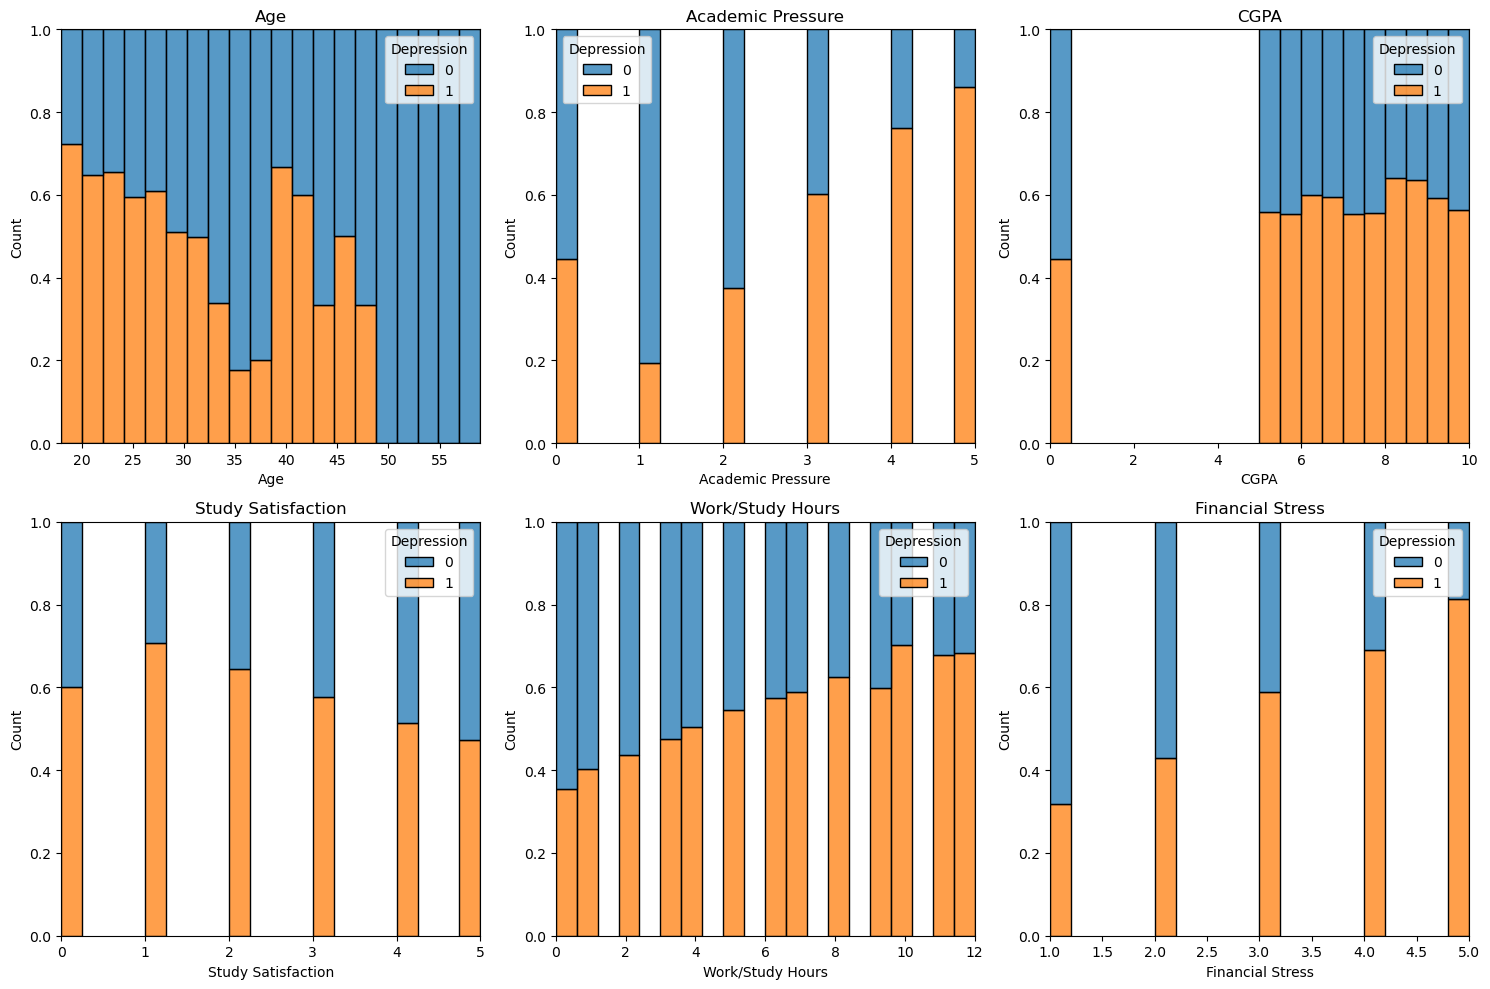

In [15]:
# Had the plots for numerical columns where each bar shows what proportion is depressed vs. not
# Also got to know that 'Age', 'Academic Pressure', 'Study Satisfaction', 'Work/Study Hours', 'Financial Stress' are strong predictors
num_columns = ['Age', 'Academic Pressure', 'CGPA', 
               'Study Satisfaction', 'Work/Study Hours', 'Financial Stress']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_columns, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data=df, x=col, hue='Depression', bins=20, multiple='fill')
    plt.title(col)
plt.tight_layout()
plt.show()

In [16]:
# Also checked average value of each feature for depressed vs non depressed people
for col in num_columns:
    print(f"--- {col} ---")
    print(df.groupby('Depression')[col].mean())
    print()

--- Age ---
Depression
0    27.142869
1    24.887297
Name: Age, dtype: float64

--- Academic Pressure ---
Depression
0    2.361757
1    3.693174
Name: Academic Pressure, dtype: float64

--- CGPA ---
Depression
0    7.617236
1    7.683713
Name: CGPA, dtype: float64

--- Study Satisfaction ---
Depression
0    3.215774
1    2.751576
Name: Study Satisfaction, dtype: float64

--- Work/Study Hours ---
Depression
0    6.237222
1    7.807346
Name: Work/Study Hours, dtype: float64

--- Financial Stress ---
Depression
0    2.518724
1    3.579553
Name: Financial Stress, dtype: float64



In [17]:
# Dropped the feature 'CGPA' as it's of no use
df = df.drop(columns=['CGPA'])

In [18]:
# Checked for the unique values in each categorical column
cat_columns = ['Gender', 'City', 'Profession', 'Sleep Duration', 
               'Dietary Habits', 'Degree', 
               'Have you ever had suicidal thoughts ?', 
               'Family History of Mental Illness']

for col in cat_columns:
    print(f"{col}: {df[col].unique()}")
    print(f"Total unique values: {df[col].nunique()}")
    print()

Gender: ['Male' 'Female']
Total unique values: 2

City: ['Visakhapatnam' 'Bangalore' 'Srinagar' 'Varanasi' 'Jaipur' 'Pune' 'Thane'
 'Chennai' 'Nagpur' 'Nashik' 'Vadodara' 'Kalyan' 'Rajkot' 'Ahmedabad'
 'Kolkata' 'Mumbai' 'Lucknow' 'Indore' 'Surat' 'Ludhiana' 'Bhopal'
 'Meerut' 'Agra' 'Ghaziabad' 'Hyderabad' 'Vasai-Virar' 'Kanpur' 'Patna'
 'Faridabad' 'Delhi' 'Saanvi' 'M.Tech' 'Bhavna' 'Less Delhi' 'City' '3.0'
 'Less than 5 Kalyan' 'Mira' 'Harsha' 'Vaanya' 'Gaurav' 'Harsh' 'Reyansh'
 'Kibara' 'Rashi' 'ME' 'M.Com' 'Nalyan' 'Mihir' 'Nalini' 'Nandini'
 'Khaziabad']
Total unique values: 52

Profession: ['Student' 'Civil Engineer' 'Architect' 'UX/UI Designer'
 'Digital Marketer' 'Content Writer' 'Educational Consultant' 'Teacher'
 'Manager' 'Chef' 'Doctor' 'Lawyer' 'Entrepreneur' 'Pharmacist']
Total unique values: 14

Sleep Duration: ['5-6 hours' 'Less than 5 hours' '7-8 hours' 'More than 8 hours' 'Others']
Total unique values: 5

Dietary Habits: ['Healthy' 'Moderate' 'Unhealthy' 'Others']


In [19]:
# Got to know that the data quality is bad in 'City' feature
print(pd.crosstab(df['City'], df['Depression'], normalize='index').round(2))

Depression             0     1
City                          
3.0                 0.00  1.00
Agra                0.47  0.53
Ahmedabad           0.33  0.67
Bangalore           0.39  0.61
Bhavna              0.00  1.00
Bhopal              0.38  0.62
Chennai             0.40  0.60
City                0.50  0.50
Delhi               0.39  0.61
Faridabad           0.41  0.59
Gaurav              0.00  1.00
Ghaziabad           0.43  0.57
Harsh               0.00  1.00
Harsha              0.50  0.50
Hyderabad           0.33  0.67
Indore              0.40  0.60
Jaipur              0.48  0.52
Kalyan              0.41  0.59
Kanpur              0.46  0.54
Khaziabad           0.00  1.00
Kibara              1.00  0.00
Kolkata             0.39  0.61
Less Delhi          1.00  0.00
Less than 5 Kalyan  1.00  0.00
Lucknow             0.45  0.55
Ludhiana            0.42  0.58
M.Com               0.00  1.00
M.Tech              1.00  0.00
ME                  1.00  0.00
Meerut              0.40  0.60
Mihir   

In [20]:
# Dropped the 'City' feature
df = df.drop(columns=['City'])

In [21]:
# Checked the frequency of unique values in the feature 'Profession'
df['Profession'].value_counts()

Profession
Student                   27867
Architect                     8
Teacher                       6
Digital Marketer              3
Content Writer                2
Chef                          2
Doctor                        2
Pharmacist                    2
Civil Engineer                1
UX/UI Designer                1
Educational Consultant        1
Manager                       1
Lawyer                        1
Entrepreneur                  1
Name: count, dtype: int64

In [22]:
# Dropped the feature 'Profession' as 'Student' profession dominates
df = df.drop(columns=['Profession'])

In [23]:
# Checked the frequency of unique values in the feature 'Sleep Duration'
df['Sleep Duration'].value_counts()

Sleep Duration
Less than 5 hours    8309
7-8 hours            7346
5-6 hours            6181
More than 8 hours    6044
Others                 18
Name: count, dtype: int64

In [24]:
# Filtered out the rows where the value of 'Sleep Duration' is 'Others'
df = df[df['Sleep Duration'] != 'Others']

In [25]:
# Computed a normalized contingency table to analyze the relationship between 'Sleep Duration' and 'Depression'
# Got to know that this feature is good
pd.crosstab(df['Sleep Duration'], df['Depression'], normalize='index').round(2)

Depression,0,1
Sleep Duration,,
5-6 hours,0.43,0.57
7-8 hours,0.40,0.60
Less than 5 hours,0.35,0.65
More than 8 hours,0.49,0.51


In [26]:
# Computed a normalized contingency table to analyze the relationship between 'Gender' and 'Depression'
pd.crosstab(df['Gender'], df['Depression'], normalize='index').round(2)

Depression,0,1
Gender,,
Female,0.42,0.58
Male,0.41,0.59


In [27]:
# Removed the feature 'Gender' as the proportions are more or less the same
df = df.drop(columns=['Gender'])

In [28]:
# Checked the frequency of unique values in the feature 'Dietary Habits'
df['Dietary Habits'].value_counts()

Dietary Habits
Unhealthy    10308
Moderate      9914
Healthy       7646
Others          12
Name: count, dtype: int64

In [29]:
# Filtered out the rows where the value of 'Dietary Habits' is 'Others'
df = df[df['Dietary Habits'] != 'Others']

In [30]:
# Computed a normalized contingency table to analyze the relationship between 'Dietary Habits' and 'Depression'
# Got to know that this feature is also worth taking into account
pd.crosstab(df['Dietary Habits'], df['Depression'], normalize='index').round(2)

Depression,0,1
Dietary Habits,,
Healthy,0.55,0.45
Moderate,0.44,0.56
Unhealthy,0.29,0.71


In [31]:
# Checked the frequency of unique values in the feature 'Degree'
df['Degree'].value_counts()

Degree
Class 12    6079
B.Ed        1864
B.Com       1504
B.Arch      1476
BCA         1431
MSc         1189
B.Tech      1151
MCA         1041
M.Tech      1020
BHM          925
BSc          886
M.Ed         819
B.Pharm      809
M.Com        734
BBA          696
MBBS         695
LLB          670
BE           611
BA           597
M.Pharm      581
MD           572
MBA          561
MA           544
PhD          520
LLM          482
MHM          191
ME           185
Others        35
Name: count, dtype: int64

In [32]:
# Computed a normalized contingency table to analyze the relationship between 'Degree' and 'Depression'
pd.crosstab(df['Degree'], df['Depression'], normalize='index').round(2)

Depression,0,1
Degree,,
B.Arch,0.41,0.59
B.Com,0.43,0.57
B.Ed,0.45,0.55
B.Pharm,0.47,0.53
B.Tech,0.43,0.57
BA,0.47,0.53
BBA,0.42,0.58
BCA,0.43,0.57
BE,0.46,0.54


In [33]:
# Dropped the feature 'Degree' as the proportion of values of the feature 'Degree' with respect to having depression is more or less the same
df = df.drop(columns=['Degree'])

In [34]:
# Checked the frequency of unique values in the feature 'Have you ever had suicidal thoughts ?'
df['Have you ever had suicidal thoughts ?'].value_counts()

Have you ever had suicidal thoughts ?
Yes    17635
No     10233
Name: count, dtype: int64

In [35]:
# Computed a normalized contingency table to analyze the relationship between 'Have you ever had suicidal thoughts ?' and 'Depression'
# Got to know that this feature is also worth taking into account
pd.crosstab(df['Have you ever had suicidal thoughts ?'], df['Depression'], normalize='index').round(2)

Depression,0,1
Have you ever had suicidal thoughts ?,,
No,0.77,0.23
Yes,0.21,0.79


In [36]:
# Checked the frequency of unique values in the feature 'Family History of Mental Illness'
df['Family History of Mental Illness'].value_counts()

Family History of Mental Illness
No     14378
Yes    13490
Name: count, dtype: int64

In [37]:
# Computed a normalized contingency table to analyze the relationship between 'Family History of Mental Illness' and 'Depression'
# Got to know that this feature is also worth taking into account due to it's real world relevance
pd.crosstab(df['Family History of Mental Illness'], df['Depression'], normalize='index').round(2)

Depression,0,1
Family History of Mental Illness,,
No,0.44,0.56
Yes,0.39,0.61


In [38]:
# Checked first few rows of the data
df.head()

,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,33.0,5.0,2.0,5-6 hours,Healthy,Yes,3.0,1.0,No,1
1,24.0,2.0,5.0,5-6 hours,Moderate,No,3.0,2.0,Yes,0
2,31.0,3.0,5.0,Less than 5 hours,Healthy,No,9.0,1.0,Yes,0
3,28.0,3.0,2.0,7-8 hours,Moderate,Yes,4.0,5.0,Yes,1
4,25.0,4.0,3.0,5-6 hours,Moderate,Yes,1.0,1.0,No,0


In [39]:
# Had the changed dimensions of the data
df.shape

(27868, 10)

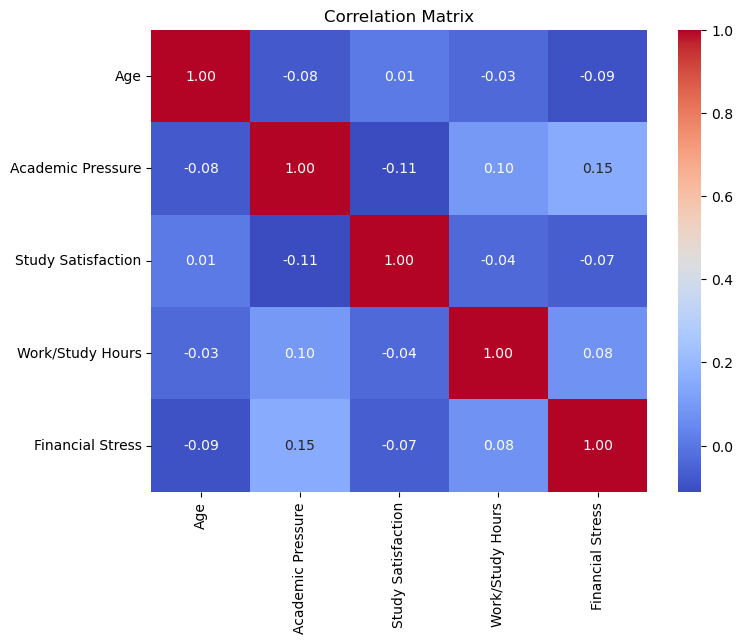

In [40]:
# Used the heatmap for visualizing correlations between numerical features
num_columns = ['Age', 'Academic Pressure', 'Study Satisfaction', 
               'Work/Study Hours', 'Financial Stress']

plt.figure(figsize=(8, 6))
sns.heatmap(df[num_columns].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [41]:
# Checked the frequency of unique values in the target 'Depression'
df['Depression'].value_counts()

Depression
1    16318
0    11550
Name: count, dtype: int64

In [42]:
# Converted categorical string columns into numerical data by replacing 'Yes' with 1 and 'No' with 0
df['Have you ever had suicidal thoughts ?'] = df['Have you ever had suicidal thoughts ?'].map({'Yes': 1, 'No': 0})
df['Family History of Mental Illness'] = df['Family History of Mental Illness'].map({'Yes': 1, 'No': 0})

In [43]:
# Checked the first few rows of the data
df.head()

,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,33.0,5.0,2.0,5-6 hours,Healthy,1,3.0,1.0,0,1
1,24.0,2.0,5.0,5-6 hours,Moderate,0,3.0,2.0,1,0
2,31.0,3.0,5.0,Less than 5 hours,Healthy,0,9.0,1.0,1,0
3,28.0,3.0,2.0,7-8 hours,Moderate,1,4.0,5.0,1,1
4,25.0,4.0,3.0,5-6 hours,Moderate,1,1.0,1.0,0,0


In [44]:
# Separated the inputs and the target
X = df.drop('Depression', axis=1)
y = df['Depression']

In [45]:
# Done the train-test split and used the stratify parameter to ensure that the training and testing sets maintain the same proportion of output labels as the original dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [46]:
# Checked the frequency of unique values in the target 'Depression' in the train, test sets
print(y_train.value_counts())
print(y_test.value_counts())

Depression
1    13054
0     9240
Name: count, dtype: int64
Depression
1    3264
0    2310
Name: count, dtype: int64


In [47]:
# Had the numerical and ordinal columns
num_columns = ['Age', 'Academic Pressure', 'Study Satisfaction', 
               'Work/Study Hours', 'Financial Stress']

ordinal_columns = ['Sleep Duration', 'Dietary Habits']

## Pipeline Creation

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Numerical Pipeline
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# Ordinal Pipeline
ordinal_pipeline = Pipeline([
    ('oe', OrdinalEncoder(categories=[
        ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours'],
        ['Unhealthy', 'Moderate', 'Healthy']
    ])),
    ('scaler', StandardScaler())
])

# Applied different data preprocessing pipelines to specific subsets of columns
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_columns),
    ('ord', ordinal_pipeline, ordinal_columns)
], remainder='passthrough') # remainder='passthrough' tells the transformer to keep any columns not explicitly mentioned in num_columns or ordinal_columns

## Dummy Classifier

In [49]:
# Had the dummy classifier score to set the baseline
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

dummy = DummyClassifier(strategy='stratified', random_state=42)
scores = cross_val_score(dummy, X_train, y_train, cv=5, scoring='f1')
print("Dummy F1 Score:", round(scores.mean(), 4))

Dummy F1 Score: 0.5841


## Model Creation With Default Parameters To Check the Validation And Train F1 Scores

### Logistic Regression

In [50]:
from sklearn.linear_model import LogisticRegression

# Created a pipeline chaining preprocessing and Logistic Regression
pipeline_of_LR = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(random_state=42))
])

In [51]:
# Had the Validation F1 Score using the Cross-Validation
val_score_of_LR = cross_val_score(pipeline_of_LR, X_train, y_train, cv=5, scoring='f1')
print('The Validation F1-Score for Logistic Regression is:', round(val_score_of_LR.mean(), 4))

The Validation F1-Score for Logistic Regression is: 0.87


In [52]:
# Trained the pipeline on training data
pipeline_of_LR.fit(X_train, y_train)

# Generate predictions using the trained pipeline on training data
pred = pipeline_of_LR.predict(X_train)

In [53]:
# Had the Train F1 Score
from sklearn.metrics import f1_score
print('The Train F1-Score for Logistic Regression is:', round(f1_score(y_train, pred), 4))

The Train F1-Score for Logistic Regression is: 0.8703


### KNN

In [54]:
from sklearn.neighbors import KNeighborsClassifier

# Created a pipeline chaining preprocessing and KNN 
pipeline_of_KNN = Pipeline([
    ('preprocessing', preprocessor),
    ('model', KNeighborsClassifier())
])

In [55]:
# Had the Validation F1 Score using the Cross-Validation
val_score_of_KNN = cross_val_score(pipeline_of_KNN, X_train, y_train, cv=5, scoring='f1')
print('The Validation F1-Score for KNN is:', round(val_score_of_KNN.mean(), 4))

The Validation F1-Score for KNN is: 0.8495


In [56]:
# Trained the pipeline on training data
pipeline_of_KNN.fit(X_train, y_train)

# Generate predictions using the trained pipeline on training data
pred = pipeline_of_KNN.predict(X_train)

In [57]:
# Had the Train F1 Score
print('The Train F1-Score for KNN is:', round(f1_score(y_train, pred), 4))

The Train F1-Score for KNN is: 0.8898


### SVM

In [58]:
from sklearn.svm import SVC

# Created a pipeline chaining preprocessing and SVM
pipeline_of_SVM = Pipeline([
    ('preprocessing', preprocessor),
    ('model', SVC())
])

In [59]:
# Had the Validation F1 Score using the Cross-Validation
val_score_of_SVM = cross_val_score(pipeline_of_SVM, X_train, y_train, cv=5, scoring='f1')
print('The Validation F1-Score for SVM is:', round(val_score_of_SVM.mean(), 4))

The Validation F1-Score for SVM is: 0.8678


In [60]:
# Trained the pipeline on training data
pipeline_of_SVM.fit(X_train, y_train)

# Generate predictions using the trained pipeline on training data
pred = pipeline_of_SVM.predict(X_train)

In [61]:
# Had the Train F1 Score
print('The Train F1-Score for SVM is:', round(f1_score(y_train, pred), 4))

The Train F1-Score for SVM is: 0.8737


### Decision Tree

In [62]:
from sklearn.tree import DecisionTreeClassifier

# Created a pipeline chaining preprocessing and DT
pipeline_of_DT = Pipeline([
    ('preprocessing', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

In [63]:
# Had the Validation F1 Score using the Cross-Validation
val_score_of_DT = cross_val_score(pipeline_of_DT, X_train, y_train, cv=5, scoring='f1')
print('The Validation F1-Score for Decision Tree is:', round(val_score_of_DT.mean(), 4))

The Validation F1-Score for Decision Tree is: 0.8003


In [64]:
# Trained the pipeline on training data
pipeline_of_DT.fit(X_train, y_train)

# Generate predictions using the trained pipeline on training data
pred = pipeline_of_DT.predict(X_train)

In [65]:
# Had the Train F1 Score
print('The Train F1-Score for Decision Tree is:', round(f1_score(y_train, pred), 4))

The Train F1-Score for Decision Tree is: 0.9979


### Random Forest

In [66]:
from sklearn.ensemble import RandomForestClassifier

# Created a pipeline chaining preprocessing and RF
pipeline_of_RF = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

In [67]:
# Had the Validation F1 Score using the Cross-Validation
val_score_of_RF = cross_val_score(pipeline_of_RF, X_train, y_train, cv=5, scoring='f1')
print('The Validation F1-Score for Random Forest is:', round(val_score_of_RF.mean(), 4))

The Validation F1-Score for Random Forest is: 0.8567


In [68]:
# Trained the pipeline on training data
pipeline_of_RF.fit(X_train, y_train)

# Generate predictions using the trained pipeline on training data
pred = pipeline_of_RF.predict(X_train)

In [69]:
# Had the Train F1 Score
print('The Train F1-Score for Random Forest is:', round(f1_score(y_train, pred), 4))

The Train F1-Score for Random Forest is: 0.9979


### XGBoost

In [70]:
from xgboost import XGBClassifier

# Created a pipeline chaining preprocessing and XGB
pipeline_of_XGB = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBClassifier(random_state=42, eval_metric='logloss'))
])

In [71]:
# Had the Validation F1 Score using the Cross-Validation
val_score_of_XGB = cross_val_score(pipeline_of_XGB, X_train, y_train, cv=5, scoring='f1')
print('The Validation F1-Score for XGBoost is:', round(val_score_of_XGB.mean(), 4))

The Validation F1-Score for XGBoost is: 0.8586


In [72]:
# Trained the pipeline on training data
pipeline_of_XGB.fit(X_train, y_train)

# Generate predictions using the trained pipeline on training data
pred = pipeline_of_XGB.predict(X_train)

In [73]:
# Had the Train F1 Score
print('The Train F1-Score for XGBoost is:', round(f1_score(y_train, pred), 4))

The Train F1-Score for XGBoost is: 0.91


### Gradient Boosting

In [74]:
from sklearn.ensemble import GradientBoostingClassifier

# Created a pipeline chaining preprocessing and GB
pipeline_of_GB = Pipeline([
    ('preprocessing', preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])

In [75]:
# Had the Validation F1 Score using the Cross-Validation
val_score_of_GB = cross_val_score(pipeline_of_GB, X_train, y_train, cv=5, scoring='f1')
print('The Validation F1-Score for Gradient Boosting is:', round(val_score_of_GB.mean(), 4))

The Validation F1-Score for Gradient Boosting is: 0.8693


In [76]:
# Trained the pipeline on training data
pipeline_of_GB.fit(X_train, y_train)

# Generate predictions using the trained pipeline on training data
pred = pipeline_of_GB.predict(X_train)

In [77]:
# Had the Validation F1 Score using the Cross-Validation
print('The Train F1-Score for Gradient Boosting is:', round(f1_score(y_train, pred), 4))

The Train F1-Score for Gradient Boosting is: 0.8749


## Based on Above Scores Three Model Were Decided For Further Hyperparameter Tuning. These were:
- **Logistic Regression**
- **SVM**
- **Gradient Boosting**

### Logistic Regression

In [78]:
from sklearn.model_selection import GridSearchCV

param_grid_LR = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__l1_ratio': [0, 1],
    'model__solver': ['liblinear', 'saga']
}

grid_LR = GridSearchCV(
    pipeline_of_LR,
    param_grid_LR,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_LR.fit(X_train, y_train)

# Had the best combination of parameters
print("Best Parameters for Logistic Regression:", grid_LR.best_params_)

# Had the best validation F1 score
print("Best Validation F1 score for Logistic Regression:", round(grid_LR.best_score_, 4))

Best Parameters for Logistic Regression: {'model__C': 0.01, 'model__l1_ratio': 0, 'model__solver': 'liblinear'}
Best Validation F1 score for Logistic Regression: 0.871


In [79]:
# Generated predictions on the training set
pred = grid_LR.best_estimator_.predict(X_train)

# Had the best train F1 score
print("Best Train F1 score for Logistic Regression:", round(f1_score(y_train, pred), 4))

Best Train F1 score for Logistic Regression: 0.8709


### SVM

In [80]:
param_grid_SVM = {
    'model__C': [0.1, 1, 10, 100],
    'model__kernel': ['rbf', 'linear'],
    'model__gamma': ['scale', 'auto']
}

grid_SVM = GridSearchCV(
    pipeline_of_SVM,
    param_grid_SVM,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_SVM.fit(X_train, y_train)

# Had the best combination of parameters
print("Best Parameters for SVM:", grid_SVM.best_params_)

# Had the best validation F1 score
print("Best Validation F1 score for SVM:", round(grid_SVM.best_score_, 4))

Best Parameters for SVM: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best Validation F1 score for SVM: 0.871


In [81]:
# Generated predictions on the training set
pred = grid_SVM.best_estimator_.predict(X_train)

# Had the best train F1 score
print("Best Train F1 score for SVM:", round(f1_score(y_train, pred), 4))

Best Train F1 score for SVM: 0.874


### Gradient Boosting

In [82]:
param_grid_GB = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 4, 5],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__subsample': [0.8, 1.0]
}

grid_GB = GridSearchCV(
    pipeline_of_GB,
    param_grid_GB,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_GB.fit(X_train, y_train)

# Had the best combination of parameters
print("Best Parameters for Gradient Boosting:", grid_GB.best_params_)

# Had the best validation F1 score
print("Best Validation F1 score for Gradient Boosting:", round(grid_GB.best_score_, 4))

Best Parameters for Gradient Boosting: {'model__learning_rate': 0.2, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 1.0}
Best Validation F1 score for Gradient Boosting: 0.8704


In [83]:
# Generated predictions on the training set
pred = grid_GB.best_estimator_.predict(X_train)

# Had the best train F1 score
print("Best Train F1 score for Gradient Boosting:", round(f1_score(y_train, pred), 4))

Best Train F1 score for Gradient Boosting: 0.8765


## Seen The Test Scores Of All Three Models To Have The Final Evaluation

In [84]:
# Generated predictions on the test set
y_test_pred_LR = grid_LR.best_estimator_.predict(X_test)

# Had the test F1 score for Logistic Regression
print("Test F1 Score for Logistic Regression:", round(f1_score(y_test, y_test_pred_LR), 4))

Test F1 Score for Logistic Regression: 0.8776


In [85]:
# Generated predictions on the test set
y_test_pred_SVM = grid_SVM.best_estimator_.predict(X_test)

# Had the test F1 score for SVM
print("Test F1 Score for SVM:", round(f1_score(y_test, y_test_pred_SVM), 4))

Test F1 Score for SVM: 0.8764


In [86]:
# Generated predictions on the test set
y_test_pred_GB = grid_GB.best_estimator_.predict(X_test)

# Had the test F1 score for SVM
print("Test F1 Score for Gradient Boosting:", round(f1_score(y_test, y_test_pred_GB), 4))

Test F1 Score for Gradient Boosting: 0.8761


              precision    recall  f1-score   support

           0       0.85      0.79      0.82      2310
           1       0.86      0.90      0.88      3264

    accuracy                           0.85      5574
   macro avg       0.85      0.84      0.85      5574
weighted avg       0.85      0.85      0.85      5574



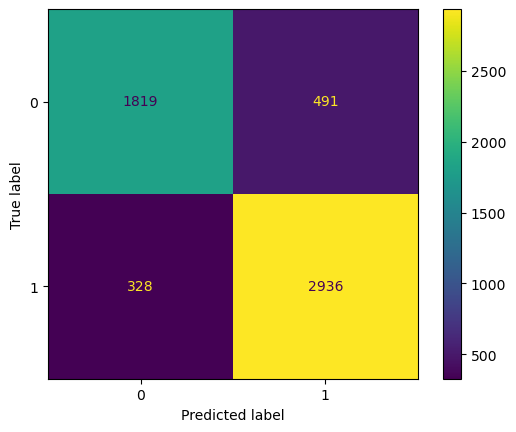

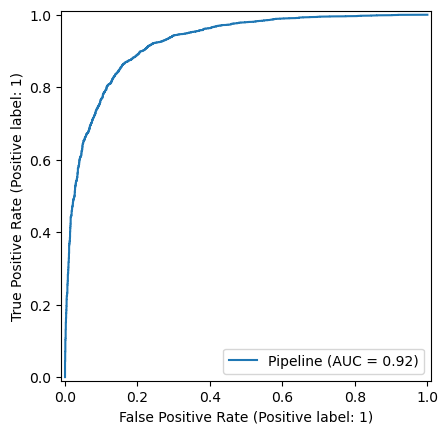

In [87]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

# Classification Report
print(classification_report(y_test, y_test_pred_LR))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(grid_LR.best_estimator_, X_test, y_test)
plt.show()

# ROC Curve
RocCurveDisplay.from_estimator(grid_LR.best_estimator_, X_test, y_test)
plt.show()

In [88]:
grid_LR.best_params_

{'model__C': 0.01, 'model__l1_ratio': 0, 'model__solver': 'liblinear'}

In [ ]:
# Final Model being trained on full data
final_model = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(
        C=0.1,
        l1_ratio=0,
        solver='liblinear',
        random_state=42
    ))
])

final_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [ ]:
# Model is saved
import joblib
joblib.dump(final_model, 'depression_model.pkl')
print("Model saved successfully!")

Model saved successfully!
